# CUSTOMER BEHAVIOUR INTELLIGENCE SYSTEM

## OBJECTIVE

The objective of this project is to analyze customer behavior and predict customer churn using machine learning techniques. The project aims to first identify hidden patterns and segment customers into meaningful groups using unsupervised learning methods. These insights are then leveraged to build supervised learning models that can accurately predict whether a customer is likely to leave the service.

By combining clustering and classification, the project seeks to improve prediction performance and provide actionable insights that can help businesses enhance customer retention, optimize marketing strategies, and make data-driven decisions.

## Loading the Dataset

In [6]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'analysis.ipynb', 'CustomerChurnDataset']


In [10]:
import zipfile
with zipfile.ZipFile("CustomerChurnDataset.zip","r") as zip_ref:
    zip_ref.extractall("CustomerChurnDataset")

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df_cust=pd.read_excel("CustomerChurnDataset/Telco_customer_churn.xlsx")
df_cust.to_csv("CustomerChurnDataset/Telco_customer_churn.csv",index=False)

In [16]:
df=df_cust.copy()

## Understanding Data

In [17]:
df.shape

(7043, 33)

In [18]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [22]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [46]:
df["Monthly Charges"].dtype

dtype('float64')

## EDA:Exploratory Data Analysis

### Target Variable Analysis

In [23]:
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

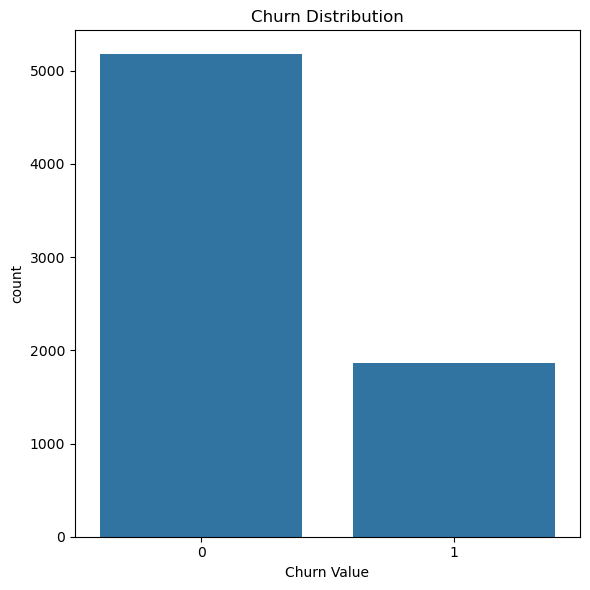

In [31]:
plt.figure(figsize=(6,6))
sns.countplot(
    data=df,
    x="Churn Value"
)
plt.title("Churn Distribution")
plt.tight_layout()
plt.show()

### Tenure V/S Churn 

In [35]:
long_tenure=np.sum(df["Tenure Months"]>24)
short_tenure=np.sum(df["Tenure Months"]<=24)
print("Longer Tenure Period:",long_tenure)
print("Shorter Tenure Period:",short_tenure)

Longer Tenure Period: 3833
Shorter Tenure Period: 3210


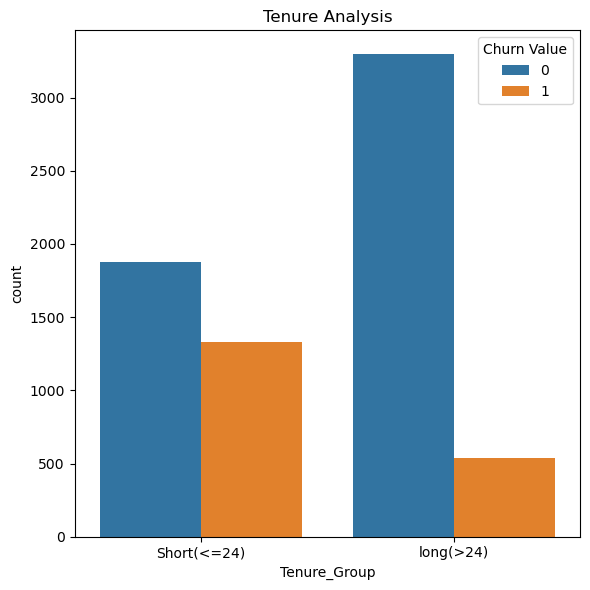

In [40]:
plt.figure(figsize=(6,6))
df["Tenure_Group"]=df["Tenure Months"].apply(lambda x:"long(>24)" if x>24 else "Short(<=24)")
sns.countplot(
    data=df,
    x="Tenure_Group",
    hue="Churn Value"
)
plt.title("Tenure Analysis")
plt.tight_layout()
plt.show()

“The graph shows that customers with shorter tenure have a higher proportion of churn compared to long-tenure customers. While a significant number of short-tenure customers leave the service, long-tenure customers predominantly remain, indicating stronger loyalty among long-term users.”

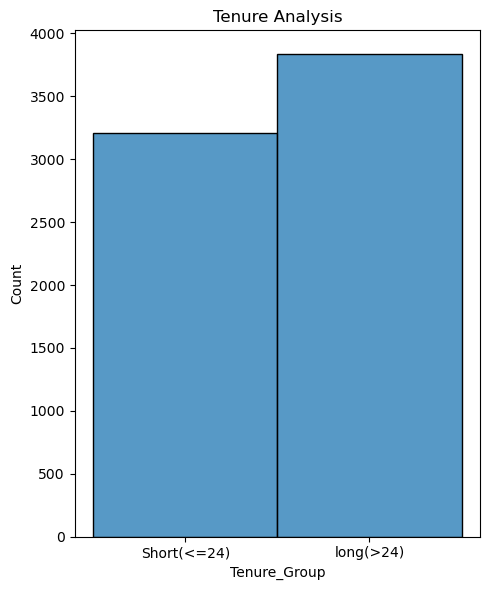

In [59]:
plt.figure(figsize=(5,6))
sns.histplot(
    data=df,
    x='Tenure_Group'
)
plt.title('Tenure Analysis')
plt.tight_layout()

### Monthly Charges V/S Churn

In [48]:
mean_monthly_charges=np.mean(df["Monthly Charges"])

In [49]:
high_monthly_charges=np.sum(df['Monthly Charges']>mean_monthly_charges)
low_monthly_charges=np.sum(df['Monthly Charges']<=mean_monthly_charges)
print("High Monthly Charges",high_monthly_charges)
print("Low Monthly Charges",low_monthly_charges)

High Monthly Charges 3923
Low Monthly Charges 3120


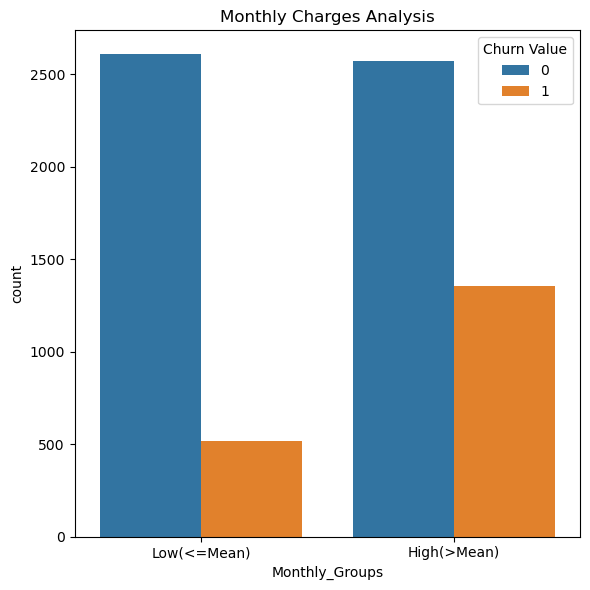

In [51]:
df["Monthly_Groups"]=df["Monthly Charges"].apply(lambda x:'High(>Mean)' if x>mean_monthly_charges else 'Low(<=Mean)')
plt.figure(figsize=(6,6))
sns.countplot(
    data=df,
    x="Monthly_Groups",
    hue="Churn Value"
)
plt.title("Monthly Charges Analysis")
plt.tight_layout()
plt.show()

“The analysis shows that customers with higher monthly charges are more likely to churn compared to those with lower charges. This suggests that pricing plays a significant role in customer retention, as customers paying higher fees may switch to more affordable alternatives.”

### Contract V/S Churn

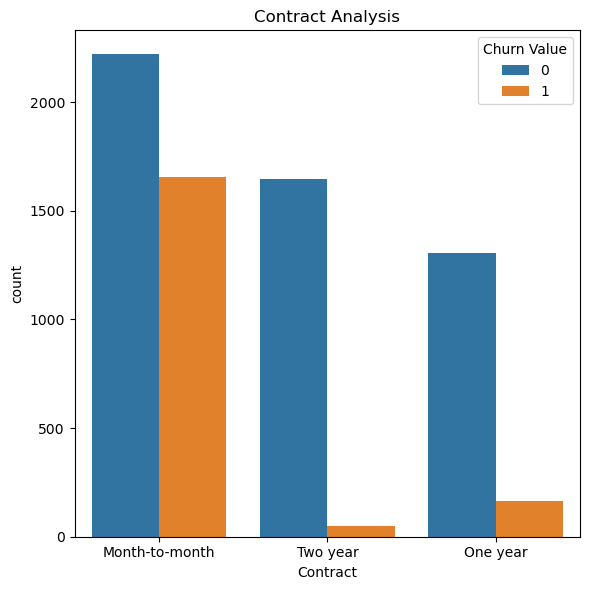

In [53]:
plt.figure(figsize=(6,6))
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn Value'
)
plt.title('Contract Analysis')
plt.tight_layout()

“Contract type is a strong predictor of churn, where shorter contract durations are associated with higher churn due to low commitment, while long-term contracts act as a retention mechanism by increasing switching costs and customer loyalty.”

### Internet Service V/S Churn

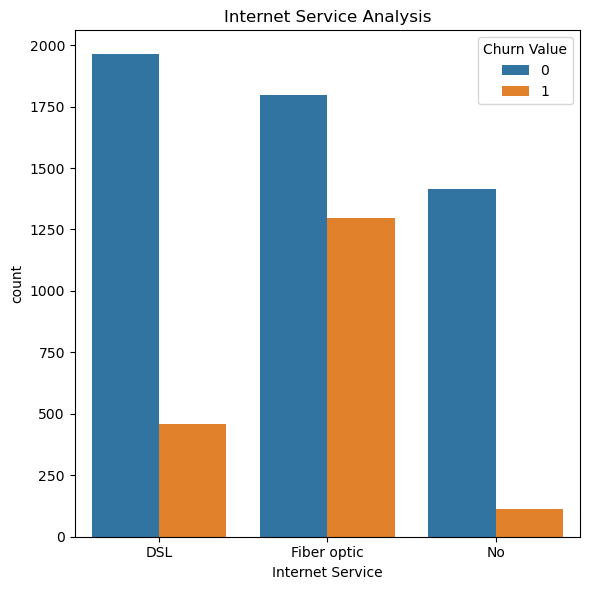

In [54]:
plt.figure(figsize=(6,6))
sns.countplot(
    data=df,
    x='Internet Service',
    hue='Churn Value'
)
plt.title('Internet Service Analysis')
plt.tight_layout()

“The analysis shows that customers using fiber optic internet services have a higher churn rate compared to DSL users, while customers with no internet service exhibit the lowest churn. This indicates that the type of internet service influences customer retention, likely due to higher costs and service expectations associated with fiber optic plans.”

### Tech Support V/S Churn

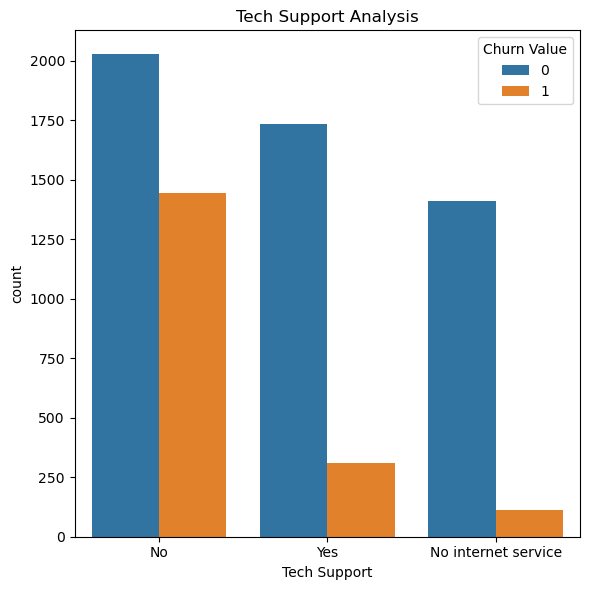

In [55]:
plt.figure(figsize=(6,6))
sns.countplot(
    data=df,
    x='Tech Support',
    hue='Churn Value'
)
plt.title('Tech Support Analysis')
plt.tight_layout()

“Tech Support is a key determinant of churn behavior. Providing technical assistance increases customer satisfaction, builds loyalty, and decreases churn risk. Lack of Tech Support correlates strongly with higher churn, highlighting the importance of value-added services in retention strategies.”

### Gender V/S Churn

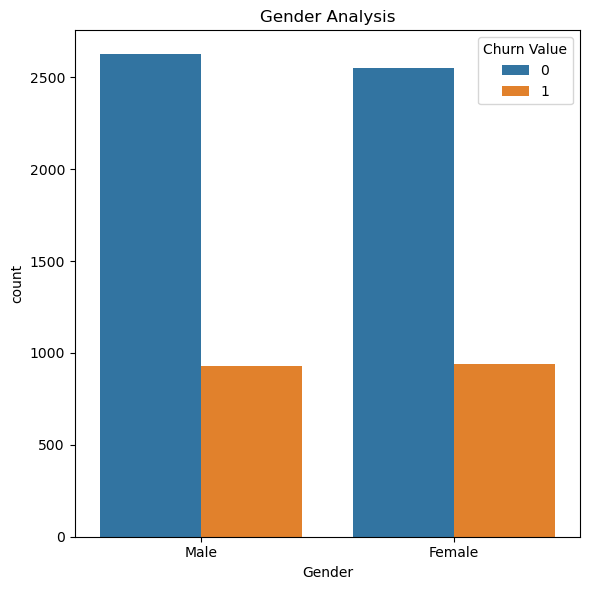

In [60]:
plt.figure(figsize=(6,6))
sns.countplot(
    data=df,
    x='Gender',
    hue='Churn Value'
)
plt.title('Gender Analysis')
plt.tight_layout()

“The analysis of gender shows that churn rates are similar between male and female customers, indicating that gender does not have a significant impact on customer churn in this dataset.”

### Senior Citizen V/S Churn

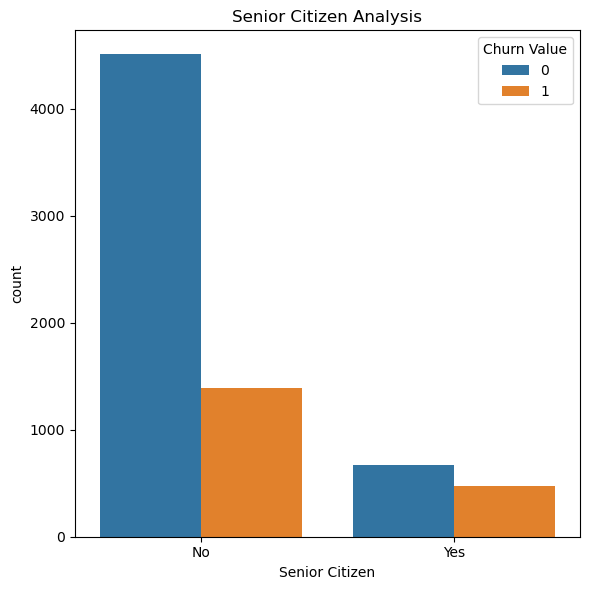

In [61]:
plt.figure(figsize=(6,6))
sns.countplot(
    data=df,
    x='Senior Citizen',
    hue='Churn Value'
)
plt.title('Senior Citizen Analysis')
plt.tight_layout()

“The analysis shows that senior citizens have a slightly higher churn rate compared to non-senior customers. This suggests that age-related factors, such as lower comfort with technology or differing service expectations, may contribute to higher churn among seniors.”

## Feature Engineering

### Handling Missing Values

In [62]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
Tenure_Group            0
Monthly_Groups          0
dtype: int64

In [64]:
df['Churn Reason']=df['Churn Reason'].fillna('No Churn')

We found that the Churn Reason column has 5174 missing values. Upon inspection, these nulls correspond to customers who did not churn. To make this column informative for analysis, we have filled the missing values with “No Churn”.

In [65]:
df.isnull().sum()

CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
Tenure_Group         0
Monthly_Groups       0
dtype: int64

### Handling Duplicate Values

In [68]:
df.duplicated().sum()

np.int64(0)

We see that there are no duplicate values in the dataset.

### Handling Data Types

In [69]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
Tenure_Group          object
Monthly_Groups

In [70]:
categorial_col=['Gender','Senior Citizen','Partner','Dependents','Phone Service','Multiple Lines','Internet Service','Online Security',
                'Online Backup','Device Protection','Tech Support','Streaming TV','Streaming Movies','Paperless Billing','Churn Label',
                'Contract','Payment Method']
for col in categorial_col:
    df[col]=df[col].astype('category')

In [71]:
df.dtypes

CustomerID             object
Count                   int64
Country                object
State                  object
City                   object
Zip Code                int64
Lat Long               object
Latitude              float64
Longitude             float64
Gender               category
Senior Citizen       category
Partner              category
Dependents           category
Tenure Months           int64
Phone Service        category
Multiple Lines       category
Internet Service     category
Online Security      category
Online Backup        category
Device Protection    category
Tech Support         category
Streaming TV         category
Streaming Movies     category
Contract             category
Paperless Billing    category
Payment Method       category
Monthly Charges       float64
Total Charges          object
Churn Label          category
Churn Value             int64
Churn Score             int64
CLTV                    int64
Churn Reason           object
Tenure_Gro

In [73]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [74]:
df.dtypes

CustomerID             object
Count                   int64
Country                object
State                  object
City                   object
Zip Code                int64
Lat Long               object
Latitude              float64
Longitude             float64
Gender               category
Senior Citizen       category
Partner              category
Dependents           category
Tenure Months           int64
Phone Service        category
Multiple Lines       category
Internet Service     category
Online Security      category
Online Backup        category
Device Protection    category
Tech Support         category
Streaming TV         category
Streaming Movies     category
Contract             category
Paperless Billing    category
Payment Method       category
Monthly Charges       float64
Total Charges         float64
Churn Label          category
Churn Value             int64
Churn Score             int64
CLTV                    int64
Churn Reason           object
Tenure_Gro

In handling Data Types, All the categorial columns are converted from object to category type and all the Numeric columns are converted from object to numeric data type

In [76]:
df.to_csv('Churn_Clean.csv',index=False)